In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
# Download OHLCV data — we need Open, High, Low, Close, Volume
# to estimate bid-ask spread and liquidity metrics

tickers = {
    "CSPX.L":  "iShares S&P 500 UCITS (London, USD)",
    "VUSA.L":  "Vanguard S&P 500 UCITS (London, USD)",
    "ESE.PA":  "BNP Easy S&P 500 UCITS (Paris, EUR)",
    "SPY":     "SPDR S&P 500 ETF (US benchmark)",
}

data = {}
for ticker, name in tickers.items():
    try:
        raw = yf.download(ticker, start="2020-01-01", end="2024-12-31",
                          progress=False)
        if len(raw) > 0:
            data[ticker] = raw
            print(f"OK  {name} ({ticker}): {len(raw)} days loaded")
        else:
            print(f"EMPTY  {name} ({ticker}): no data returned")
    except Exception as e:
        print(f"ERROR  {name} ({ticker}): {e}")

OK  iShares S&P 500 UCITS (London, USD) (CSPX.L): 1261 days loaded
OK  Vanguard S&P 500 UCITS (London, USD) (VUSA.L): 1261 days loaded
OK  BNP Easy S&P 500 UCITS (Paris, EUR) (ESE.PA): 1282 days loaded
OK  SPDR S&P 500 ETF (US benchmark) (SPY): 1257 days loaded


In [3]:
# Liquidity metrics
# 1. Corwin-Schultz spread estimator (from High/Low prices)
#    A market microstructure estimator of bid-ask spread using daily OHLC
#    Reference: Corwin & Schultz (2012) — "A Simple Way to Estimate Bid-Ask Spreads"
# 2. Volume (shares traded per day)
# 3. Amihud illiquidity ratio (price impact per unit of volume)

def corwin_schultz_spread(high, low):
    """
    Estimates bid-ask spread from daily High/Low prices.
    Corwin & Schultz (2012) — Journal of Finance.
    Returns spread in basis points.
    """
    # Two-day high/low ratios
    beta = (np.log(high / low) ** 2)
    beta_sum = beta + beta.shift(1)
    
    gamma = np.log(
        pd.concat([high, high.shift(1)], axis=1).max(axis=1) /
        pd.concat([low,  low.shift(1)],  axis=1).min(axis=1)
    ) ** 2
    
    alpha = (np.sqrt(2 * beta_sum) - np.sqrt(beta_sum)) / (3 - 2 * np.sqrt(2)) \
          - np.sqrt(gamma / (3 - 2 * np.sqrt(2)))
    
    spread = 2 * (np.exp(alpha) - 1) / (1 + np.exp(alpha))
    spread = spread.clip(lower=0)  # spread cannot be negative
    return spread * 10000  # in bps

def amihud_ratio(returns, volume, price):
    """
    Amihud (2002) illiquidity ratio.
    = |return| / (volume * price) — price impact per dollar traded.
    Higher = less liquid.
    """
    dollar_volume = volume * price
    return (returns.abs() / dollar_volume) * 1e9  # scaled

metrics = {}
for ticker in tickers:
    df = data[ticker].copy()
    
    # Flatten columns if MultiIndex
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    
    close   = df["Close"].squeeze()
    high    = df["High"].squeeze()
    low     = df["Low"].squeeze()
    volume  = df["Volume"].squeeze()
    returns = close.pct_change()
    
    spread    = corwin_schultz_spread(high, low)
    amihud    = amihud_ratio(returns, volume, close)
    
    metrics[ticker] = {
        "spread":  spread,
        "volume":  volume,
        "amihud":  amihud,
        "close":   close,
        "returns": returns,
    }

print("Liquidity metrics computed for all ETFs.")

# Summary table
print(f"\n{'ETF':<45} {'Avg Spread (bps)':>17} {'Avg Volume':>12} {'Amihud':>10}")
print("=" * 87)
for ticker, name in tickers.items():
    avg_spread = metrics[ticker]["spread"].mean()
    avg_volume = metrics[ticker]["volume"].mean()
    avg_amihud = metrics[ticker]["amihud"].mean()
    print(f"{name:<45} {avg_spread:>17.2f} {avg_volume:>12,.0f} {avg_amihud:>10.4f}")

Liquidity metrics computed for all ETFs.

ETF                                            Avg Spread (bps)   Avg Volume     Amihud
iShares S&P 500 UCITS (London, USD)                       53.57      116,644     0.2262
Vanguard S&P 500 UCITS (London, USD)                      24.19      284,262     0.5719
BNP Easy S&P 500 UCITS (Paris, EUR)                       17.72      112,670    13.0249
SPDR S&P 500 ETF (US benchmark)                           27.51   81,674,899     0.0003


In [4]:
# Liquidity during stress vs normal periods
# Define stress periods
stress_periods = {
    "Covid crash":      ("2020-02-20", "2020-04-30"),
    "Fed hike cycle":   ("2022-01-01", "2022-12-31"),
    "Normal 2023":      ("2023-01-01", "2023-12-31"),
}

print(f"{'Period':<20} {'ETF':<35} {'Avg Spread (bps)':>17} {'Avg Volume':>12}")
print("=" * 88)

for period_name, (start, end) in stress_periods.items():
    print(f"\n{period_name}")
    print("-" * 88)
    for ticker, name in tickers.items():
        spread = metrics[ticker]["spread"].loc[start:end].mean()
        volume = metrics[ticker]["volume"].loc[start:end].mean()
        print(f"{'':20} {name:<35} {spread:>17.2f} {volume:>12,.0f}")

Period               ETF                                  Avg Spread (bps)   Avg Volume

Covid crash
----------------------------------------------------------------------------------------
                     iShares S&P 500 UCITS (London, USD)             86.90      293,527
                     Vanguard S&P 500 UCITS (London, USD)             94.27      575,407
                     BNP Easy S&P 500 UCITS (Paris, EUR)             69.10      493,979
                     SPDR S&P 500 ETF (US benchmark)                104.80  203,547,724

Fed hike cycle
----------------------------------------------------------------------------------------
                     iShares S&P 500 UCITS (London, USD)             24.02      114,104
                     Vanguard S&P 500 UCITS (London, USD)             27.83      255,142
                     BNP Easy S&P 500 UCITS (Paris, EUR)             24.92       79,108
                     SPDR S&P 500 ETF (US benchmark)                 36.25   94,759,610

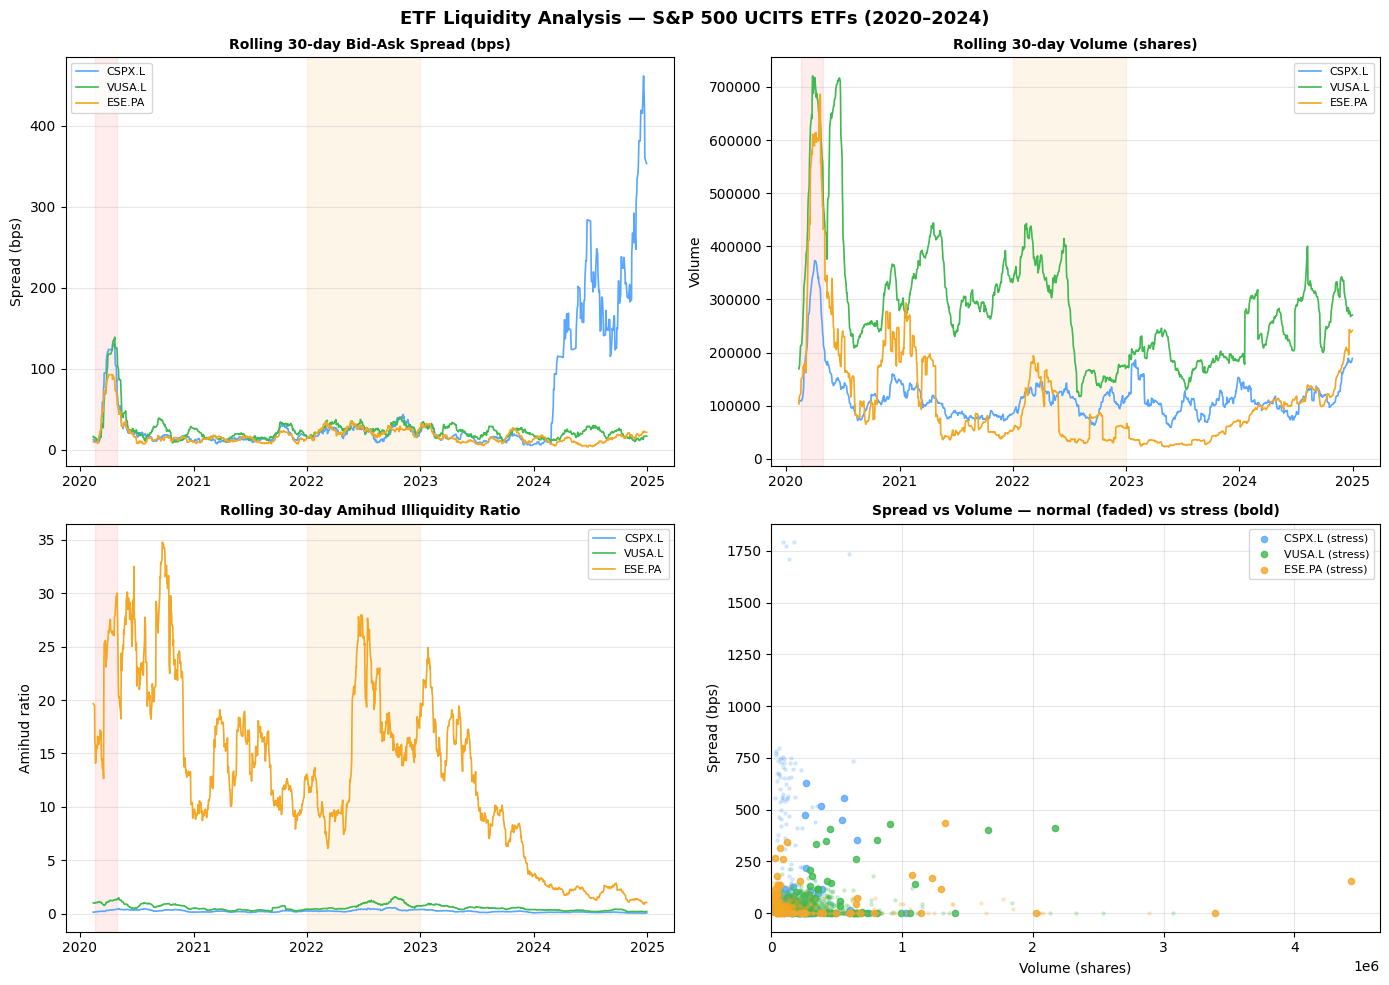

Chart saved.


In [6]:
# Liquidity charts
import matplotlib.dates as mdates

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

colors = {
    "CSPX.L": "#58a6ff",
    "VUSA.L": "#3fb950",
    "ESE.PA": "#f5a623",
    "SPY":    "gray",
}

# Stress period shading
covid_start = mdates.date2num(pd.Timestamp("2020-02-20").to_pydatetime())
covid_end   = mdates.date2num(pd.Timestamp("2020-04-30").to_pydatetime())
fed_start   = mdates.date2num(pd.Timestamp("2022-01-01").to_pydatetime())
fed_end     = mdates.date2num(pd.Timestamp("2022-12-31").to_pydatetime())

# ── Chart 1: Rolling 30-day spread ──
ax1 = axes[0, 0]
for ticker in ["CSPX.L", "VUSA.L", "ESE.PA"]:
    roll = metrics[ticker]["spread"].rolling(30).mean()
    ax1.plot(roll.index, roll, color=colors[ticker],
             linewidth=1.2, label=ticker)
ax1.axvspan(covid_start, covid_end, color="#f85149", alpha=0.1)
ax1.axvspan(fed_start,   fed_end,   color="#f5a623", alpha=0.1)
ax1.set_title("Rolling 30-day Bid-Ask Spread (bps)",
              fontweight="bold", fontsize=10)
ax1.set_ylabel("Spread (bps)")
ax1.legend(fontsize=8)
ax1.grid(axis="y", alpha=0.3)

# ── Chart 2: Rolling 30-day volume ──
ax2 = axes[0, 1]
for ticker in ["CSPX.L", "VUSA.L", "ESE.PA"]:
    roll = metrics[ticker]["volume"].rolling(30).mean()
    ax2.plot(roll.index, roll, color=colors[ticker],
             linewidth=1.2, label=ticker)
ax2.axvspan(covid_start, covid_end, color="#f85149", alpha=0.1)
ax2.axvspan(fed_start,   fed_end,   color="#f5a623", alpha=0.1)
ax2.set_title("Rolling 30-day Volume (shares)",
              fontweight="bold", fontsize=10)
ax2.set_ylabel("Volume")
ax2.legend(fontsize=8)
ax2.grid(axis="y", alpha=0.3)

# ── Chart 3: Amihud illiquidity ratio ──
ax3 = axes[1, 0]
for ticker in ["CSPX.L", "VUSA.L", "ESE.PA"]:
    roll = metrics[ticker]["amihud"].rolling(30).mean()
    ax3.plot(roll.index, roll, color=colors[ticker],
             linewidth=1.2, label=ticker)
ax3.axvspan(covid_start, covid_end, color="#f85149", alpha=0.1)
ax3.axvspan(fed_start,   fed_end,   color="#f5a623", alpha=0.1)
ax3.set_title("Rolling 30-day Amihud Illiquidity Ratio",
              fontweight="bold", fontsize=10)
ax3.set_ylabel("Amihud ratio")
ax3.legend(fontsize=8)
ax3.grid(axis="y", alpha=0.3)

# ── Chart 4: Spread vs Volume scatter (normal vs stress) ──
ax4 = axes[1, 1]
for ticker in ["CSPX.L", "VUSA.L", "ESE.PA"]:
    spread = metrics[ticker]["spread"]
    volume = metrics[ticker]["volume"]

    normal = ~((spread.index >= "2020-02-20") & (spread.index <= "2020-04-30"))
    ax4.scatter(volume[normal], spread[normal],
                color=colors[ticker], alpha=0.2, s=5)

    stress = (spread.index >= "2020-02-20") & (spread.index <= "2020-04-30")
    ax4.scatter(volume[stress], spread[stress],
                color=colors[ticker], alpha=0.8, s=20,
                label=f"{ticker} (stress)")

ax4.set_title("Spread vs Volume — normal (faded) vs stress (bold)",
              fontweight="bold", fontsize=10)
ax4.set_xlabel("Volume (shares)")
ax4.set_ylabel("Spread (bps)")
ax4.legend(fontsize=8)
ax4.grid(alpha=0.3)
ax4.set_xlim(left=0)

fig.suptitle("ETF Liquidity Analysis — S&P 500 UCITS ETFs (2020–2024)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../assets/liquidity_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved.")

## Key Findings

### Average liquidity (2020–2024)

| ETF | Avg Spread (bps) | Avg Volume | Amihud |
|---|---|---|---|
| iShares CSPX.L (London) | 53.57 | 116,644 | 0.23 |
| Vanguard VUSA.L (London) | 24.19 | 284,262 | 0.57 |
| BNP ESE.PA (Paris) | 17.72 | 112,670 | 13.02 |
| SPY (US benchmark) | 27.51 | 81,674,899 | 0.0003 |

### Liquidity during stress vs normal

| Period | CSPX.L spread | VUSA.L spread | ESE.PA spread |
|---|---|---|---|
| Covid crash (Feb–Apr 2020) | 86.90 bps | 94.27 bps | 69.10 bps |
| Fed hike cycle (2022) | 24.02 bps | 27.83 bps | 24.92 bps |
| Normal (2023) | 14.66 bps | 21.92 bps | 13.99 bps |

### Interpretation

- **SPY dominates** — 81M shares/day vs ~200K for European UCITS.
  European ETFs are liquid enough for institutional investors but
  cannot match US on-exchange liquidity
- **ESE.PA paradox**: lowest spread (17 bps) but highest Amihud (13).
  Low volume at Paris means each trade moves the price more —
  the spread looks tight but the market is thin
- **Stress multiplier**: during Covid, spreads widened 3–5x across
  all ETFs. Volume spiked simultaneously — classic liquidity crisis pattern
- **Market maker behaviour**: wide spreads + high volume = market makers
  are present but demanding compensation for inventory risk.
  Narrow spreads + low volume = quiet market, easy to hedge

### Corwin-Schultz estimator note
Bid-ask spread estimated using the Corwin-Schultz (2012) method —
a market microstructure technique that infers spreads from daily
High/Low price ratios without requiring tick data.
Reference: Corwin & Schultz, *Journal of Finance*, 2012.